In [1]:
import numpy as np
from torchvision.datasets import CocoDetection
import datetime
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import sys 
sys.path.append("/home/tyfei/cyroem")
import utils
import torch
import importlib 
import json
import modules
importlib.reload(utils)
importlib.reload(modules)
import torchmetrics
import data

import pycocotools.coco
import pycocotools.mask
import torchvision.transforms.v2 as transforms
from transformers import DetrConfig, DetrForObjectDetection, DetrImageProcessor, DetrForSegmentation, ConditionalDetrForObjectDetection,ConditionalDetrConfig,ConditionalDetrForSegmentation

/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_final/whole_continue_mask", "epoch100_last.ckpt")
model = model.eval() 

Some weights of ConditionalDetrForObjectDetection were not initialized from the model checkpoint at microsoft/conditional-detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.bias: found shape torch.Size([91]) in the checkpoint and torch.Size([5]) in the model instantiated
- class_labels_classifier.weight: found shape torch.Size([91, 256]) in the checkpoint and torch.Size([5, 256]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


model at stage  stage mask


/home/feity/cryoem/utils.py:807: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  t = torch.load(configs["model"]["load"], map_location="cpu")


incompatible parameters ['gnn.pe']
finish loading parameters


/home/feity/cryoem/utils.py:845: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(path, checkpoint), map_location="cpu")["state_dict"]


incompatible parameters ['gnn.pe']
finish loading parameters


In [7]:
i="sllt0039_9_5.pkl"
dataset = data.CocoDetection(
"/data/transformer_project/transforemer_model/train_data/training/data/", 
"/data/transformer_project/transforemer_model/train_data/training/data/annotations/"+i,
                            is_npy=True, filter_class=[3, 4, 7, 12, 14], map_class={"3":0, "4":1, "7":2, "12":3, "14":4}, require_mask=True, transform=data.getConstantTransform(), add_classname=True, norm="hist",filtermin=5
)
model.stage = "stage 1"
retdict = utils.buildStage2(model, dataset, (800, 800), 0.05, has_none=False, empty=5)
graph = utils.convertStage2Dataset(retdict)


loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
slice 0
check whether reserve  tensor(173) tensor(173)
torch.Size([173]) torch.Size([173, 4])
obj_cnts: 173
slice 1
check whether reserve  tensor(225) tensor(225)
torch.Size([225]) torch.Size([225, 4])
obj_cnts: 398
slice 2
check whether reserve  tensor(213) tensor(213)
torch.Size([213]) torch.Size([213, 4])
obj_cnts: 611
slice 3
check whether reserve  tensor(230) tensor(230)
torch.Size([230]) torch.Size([230, 4])
obj_cnts: 841
slice 4
check whether reserve  tensor(227) tensor(228)
torch.Size([228]) torch.Size([228, 4])
obj_cnts: 1069
slice 5
check whether reserve  tensor(224) tensor(224)
torch.Size([224]) torch.Size([224, 4])
obj_cnts: 1293
slice 6
check whether reserve  tensor(212) tensor(212)
torch.Size([212]) torch.Size([212, 4])
obj_cnts: 1505
slice 7
check whether reserve  tensor(207) tensor(207)
torch.Size([207]) torch.Size([207, 4])
obj_cnts: 1712
slice 8
check whether reserve  tensor(222) tensor

In [8]:
np.unique(graph.x[:, 0].numpy())

array([0.22, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33, 0.34, 0.35, 0.36,
       0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47,
       0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58,
       0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69,
       0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8 ],
      dtype=float32)

In [9]:
graph
z = graph.x[:, [0]]
boxes = graph.boxes
labels = graph.y.unsqueeze(1)
df = torch.cat([z, boxes, labels], dim=1)

target_df = pd.DataFrame(df.numpy(), columns=["z", "x", "y", "w", "h", "label"])
target_df["z"] = target_df["z"]*500 
target_df["z"] = target_df["z"].astype(int)
target_df["label"] = target_df["label"].astype(int)
target_df = target_df[target_df["label"] != 5]
target_df["name"] = target_df["label"].map({0:"ribo", 1:"microtubule", 2:"nucleus", 3:"endoplasmic_reticulum_or_Golgi", 4:"mitochondria"})

bboxes = target_df[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([800, 800, 800, 800])
target_df[["x1", "y1", "x2", "y2"]] = bboxes.numpy()
target_df

/tmp/ipykernel_1962124/3419895041.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([800, 800, 800, 800])


,z,x,y,w,h,label,name,x1,y1,x2,y2
149,110,0.150000,0.522500,0.30000,0.95500,2,nucleus,0.000000,35.999989,240.000015,800.000000
184,135,0.399375,0.758750,0.10625,0.20000,4,mitochondria,277.000000,527.000000,362.000000,687.000061
195,135,0.286250,0.574375,0.01250,0.01625,0,ribo,224.000000,452.999969,233.999985,466.000000
257,135,0.300000,0.281250,0.02500,0.02500,0,ribo,230.000015,215.000015,250.000000,234.999985
266,135,0.308125,0.376250,0.01875,0.01500,0,ribo,238.999985,295.000000,254.000000,307.000000
...,...,...,...,...,...,...,...,...,...,...,...
11647,400,0.800625,0.585625,0.01375,0.01125,0,ribo,635.000061,464.000000,646.000000,473.000000
11717,400,0.944375,0.581250,0.01375,0.01500,0,ribo,750.000000,459.000000,760.999939,471.000000
11724,400,0.762500,0.749375,0.31750,0.33875,4,mitochondria,483.000000,464.000000,737.000000,735.000000
11743,400,0.906250,0.460000,0.18750,0.11750,3,endoplasmic_reticulum_or_Golgi,650.000000,321.000000,800.000000,415.000000


In [10]:
target_df["name"].value_counts()

name
ribo                              647
endoplasmic_reticulum_or_Golgi    140
microtubule                       136
mitochondria                       71
nucleus                            26
Name: count, dtype: int64

In [11]:
model.stage = "stage 2"
model.eval()
with torch.no_grad():
    res = model(graph.x, graph.edge_index)
z = graph.x[:, [0]]
prob = torch.softmax(res["predict"], 1)
pred_boxes = res["box"]

In [12]:
df = torch.cat([z, pred_boxes, prob], 1)
df = df.detach().numpy()
df = pd.DataFrame(df, columns=["z", "x", "y", "w", "h", "ribo", "microtubule", "nucleus", "endoplasmic_reticulum_or_Golgi", "mitochondria", "None"])
df["z"] = df["z"]*500
df["z"] = df["z"].astype(int)
bboxes = df[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([800, 800, 800, 800])
df[["x1", "y1", "x2", "y2"]] = bboxes.numpy()

subdf = df[["ribo", "microtubule", "nucleus", "endoplasmic_reticulum_or_Golgi", "mitochondria"]]
v = subdf.values 
v = v > np.array([0.75, 0.3, 0.3, 0.4, 0.4]) 
v = v.any(axis=1) 
df["max"] = subdf.max(axis=1)
df["largest"] = subdf.idxmax(axis=1)
df["prob"] = v
df

/tmp/ipykernel_1962124/268179625.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([800, 800, 800, 800])


,z,x,y,w,h,ribo,microtubule,nucleus,endoplasmic_reticulum_or_Golgi,mitochondria,None,x1,y1,x2,y2,max,largest,prob
0,110,0.315278,0.085552,0.015051,0.009545,0.082265,0.000023,0.000038,0.000116,5.188583e-07,0.917558,246.201675,64.623512,258.242859,72.259460,0.082265,ribo,False
1,110,0.117891,0.198786,0.150061,0.219984,0.011657,0.003298,0.011654,0.158605,3.514652e-02,0.779638,34.288235,71.035034,154.336929,247.022278,0.158605,endoplasmic_reticulum_or_Golgi,False
2,110,0.301094,0.453695,0.017822,0.018102,0.155651,0.000377,0.000014,0.000123,2.681914e-07,0.843835,233.746689,355.714813,248.004181,370.196564,0.155651,ribo,False
3,110,0.378805,0.570562,0.009064,0.010597,0.014952,0.000003,0.000040,0.000027,1.220081e-06,0.984977,299.418732,452.210754,306.669861,460.688171,0.014952,ribo,False
4,110,0.227257,0.373225,0.015804,0.015457,0.102943,0.000055,0.000012,0.000034,2.066725e-07,0.896955,175.484039,292.397003,188.127167,304.762482,0.102943,ribo,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11769,400,0.875854,0.834795,0.022650,0.022056,0.564707,0.000424,0.000022,0.000082,1.736429e-07,0.434764,691.623413,659.013489,709.743713,676.658508,0.564707,ribo,False
11770,400,0.643005,0.971629,0.045175,0.041965,0.413527,0.000653,0.000087,0.000469,1.260639e-06,0.585263,496.333923,760.517334,532.474060,794.089294,0.413527,ribo,False
11771,400,0.540545,0.323245,0.019876,0.019460,0.492545,0.000239,0.000016,0.000096,1.110564e-07,0.507104,424.485779,250.812317,440.386292,266.380463,0.492545,ribo,False
11772,400,0.851763,0.187242,0.025467,0.028019,0.250154,0.000104,0.000035,0.000224,3.239550e-07,0.749483,671.223755,138.585938,691.597290,161.001099,0.250154,ribo,False


In [13]:
subdf = df[df["prob"]]
subdf["largest"].value_counts()

largest
ribo                              973
microtubule                       302
endoplasmic_reticulum_or_Golgi    289
nucleus                            70
mitochondria                       68
Name: count, dtype: int64

In [14]:
nms = {"ribo":0.2, "microtubule":0.5, "nucleus":0.2, "endoplasmic_reticulum_or_Golgi":0.6, "mitochondria":0.2, "None":1.2}
alldfs = []
for i, subdf in df.groupby(["z", "largest"]):
    # print(subdf.head())
    if i[1] == "None":
        continue
    keep = utils.bbnms(nms[i[1]], utils.convertBoxes(torch.tensor(subdf[["x", "y", "w", "h"]].values)), torch.tensor(subdf["max"].values), subdf["largest"].values)
    # print(i, keep)
    subdf["bbnms"] = False
    subdf.loc[subdf.index[keep.numpy()], "bbnms"] = True
    alldfs.append(subdf)
df = pd.concat(alldfs)
df["final"] = df["bbnms"] & df["prob"]
df["final"].sum()

1514

In [15]:
subdf = df[df["prob"]]
subdf["largest"].value_counts()

largest
ribo                              973
microtubule                       302
endoplasmic_reticulum_or_Golgi    289
nucleus                            70
mitochondria                       68
Name: count, dtype: int64

In [16]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.datasets import load_digits
from scipy.spatial.distance import pdist, squareform

def get_labels(subdf, min_samples=1, eps=0.4, penalty=0.04, expand=0.05, squared = False):
    hdb = DBSCAN(min_samples=min_samples, eps = eps, metric='precomputed')
    xywh = subdf[["x", "y", "w", "h"]].values
    xywh[:, 2:] += expand
    iou = utils.get_iou(xywh)
    iou = 1 - iou
    mask = subdf["z"].values 
    mask = mask[:, None] == mask[None, :]
    iou[mask] = 2
    mask = subdf["z"].values 
    if squared:
        dis_penalty = np.abs(mask[:, None] - mask[None, :]) ** 2 * penalty
    else:
        dis_penalty = np.abs(mask[:, None] - mask[None, :]) * penalty
    
    iou = iou + dis_penalty
    hdb.fit(iou)  
    return hdb.labels_
    #subdf["label"] = hdb.labels_
# np.unique(hdb.labels_).tolist()

In [17]:
params = {
    "ribo":{"min_samples":1, "eps":0.4, "penalty":0.1/25, "expand":0.03, "squared":True},
    "nucleus":{"min_samples":5, "eps":0.4, "penalty":0.01, "expand":0.00, "squared":False},
    'mitochondria':{"min_samples":2, "eps":0.4, "penalty":0.02, "expand":0.00, "squared":False},
    "microtubule":{"min_samples":1, "eps":0.4, "penalty":0.05/25, "expand":0.03, "squared":True},
    'endoplasmic_reticulum_or_Golgi':{"min_samples":2, "eps":0.4, "penalty":0.02, "expand":0.00, "squared":False},
}

afterDBSCAN = [] 
for i, subdf in df.groupby(["largest"]):
    # print(subdf.head())
    print(i)
    if i == "None":
        continue
    subdf = subdf[subdf["final"]]
    if len(subdf) > 0:
        # print(i, len(subdf))
        labels = get_labels(subdf, **params[i[0]])
        print(i, len(subdf), len(np.unique(labels)))
        subdf["label"] = list(labels)
        afterDBSCAN.append(subdf)
    # print(i, subdf["label"].unique())

('endoplasmic_reticulum_or_Golgi',)
('endoplasmic_reticulum_or_Golgi',) 260 36
('microtubule',)
('microtubule',) 264 49
('mitochondria',)
('mitochondria',) 48 3
('nucleus',)
('nucleus',) 42 3
('ribo',)
('ribo',) 900 224


/tmp/ipykernel_1962124/1243023980.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf["label"] = list(labels)
/tmp/ipykernel_1962124/1243023980.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf["label"] = list(labels)
/tmp/ipykernel_1962124/1243023980.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

In [18]:
df = pd.concat(afterDBSCAN)
np.unique(df["label"])

array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,
        12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,
        25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
        38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
        51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
        64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
        77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
        90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
       103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115,
       116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128,
       129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
       142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154,
       155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
       168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 17

In [19]:
subdf = df[df["label"] >= 0]
subdf["largest"].value_counts()

largest
ribo                              698
microtubule                       222
endoplasmic_reticulum_or_Golgi    158
mitochondria                       45
nucleus                            22
Name: count, dtype: int64

['ribo' 'ribo' 'endoplasmic_reticulum_or_Golgi' 'ribo' 'ribo'
 'endoplasmic_reticulum_or_Golgi' 'mitochondria' 'ribo' 'microtubule'
 'ribo' 'ribo' 'endoplasmic_reticulum_or_Golgi' 'ribo' 'microtubule'
 'ribo' 'ribo' 'endoplasmic_reticulum_or_Golgi' 'microtubule'
 'endoplasmic_reticulum_or_Golgi' 'endoplasmic_reticulum_or_Golgi' 'ribo'
 'ribo' 'ribo']


/tmp/ipykernel_1962124/4022344118.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/utils.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image * 255).type(torch.uint8)
/home/feity/cryoem/utils.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torchvision/uti

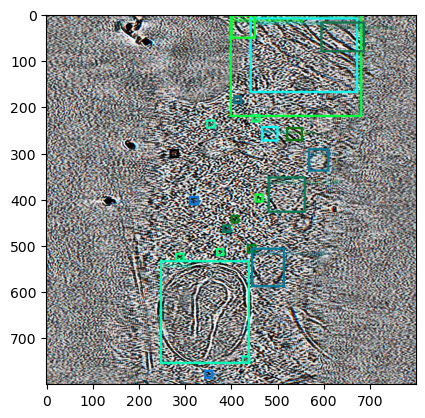

/tmp/ipykernel_1962124/4022344118.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/utils.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image * 255).type(torch.uint8)
/home/feity/cryoem/utils.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torchvision/uti

['ribo' 'endoplasmic_reticulum_or_Golgi' 'ribo'
 'endoplasmic_reticulum_or_Golgi' 'ribo' 'mitochondria' 'ribo'
 'microtubule' 'ribo' 'endoplasmic_reticulum_or_Golgi' 'microtubule'
 'ribo' 'microtubule' 'ribo' 'ribo' 'ribo' 'ribo'
 'endoplasmic_reticulum_or_Golgi' 'endoplasmic_reticulum_or_Golgi'
 'endoplasmic_reticulum_or_Golgi' 'ribo' 'endoplasmic_reticulum_or_Golgi'
 'ribo']


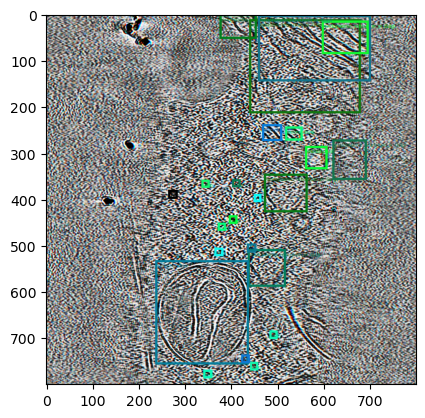

/tmp/ipykernel_1962124/4022344118.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/utils.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image * 255).type(torch.uint8)
/home/feity/cryoem/utils.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torchvision/uti

['endoplasmic_reticulum_or_Golgi' 'ribo' 'ribo' 'ribo'
 'endoplasmic_reticulum_or_Golgi' 'ribo' 'mitochondria' 'ribo'
 'microtubule' 'ribo' 'ribo' 'ribo' 'endoplasmic_reticulum_or_Golgi'
 'ribo' 'microtubule' 'ribo' 'microtubule' 'ribo' 'ribo'
 'endoplasmic_reticulum_or_Golgi' 'ribo' 'microtubule' 'ribo' 'ribo'
 'ribo' 'ribo' 'endoplasmic_reticulum_or_Golgi' 'ribo'
 'endoplasmic_reticulum_or_Golgi' 'ribo']


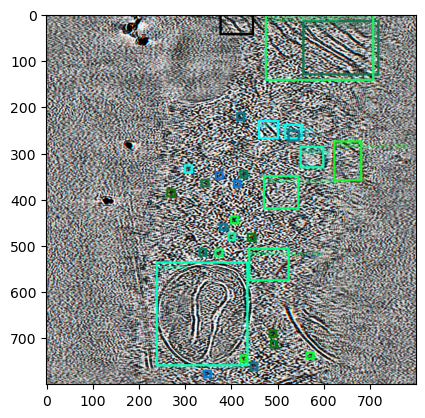

In [20]:
for take in range(25, 28):
    need = [] 
    for i in retdict["sample_mapping"]:
        if retdict["sample_mapping"][i] == take and i in df.index:
            need.append(i) 
    img = retdict["images"][take] 
    subdf2 = df.loc[need] 
    subdf2 = subdf2[subdf2["label"] >= 0]
    bboxes = subdf2[["x", "y", "w", "h"]].values
    bboxes = utils.convertBoxes(torch.tensor(bboxes))
    bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
    labels = {"bboxes": bboxes, "labels": subdf2["largest"].values} 
    print(subdf2["largest"].values)
    utils.drawannotation(img, labels, font_size=100)
    plt.show()

In [21]:
take = 9
need = []
for i in retdict["sample_mapping"]:
    if retdict["sample_mapping"][i] == take and i in df.index:
        need.append(i)
        
img = retdict["images"][take]
subdf2 = df.loc[need]

""" if use dbscan results """
# subdf2 = subdf2[subdf2["label"] != -1]
# subdf2["label"] = subdf2["label"].astype("str")

' if use dbscan results '

/tmp/ipykernel_1962124/1290441965.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/utils.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image * 255).type(torch.uint8)
/home/feity/cryoem/utils.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torchvision/util

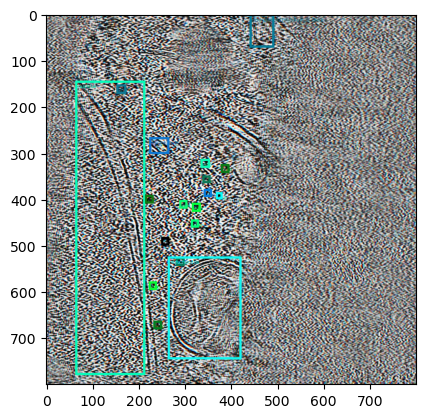

In [22]:
bboxes = subdf2[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
# bboxes, img.shape
# subdf2["label"] = subdf2["label"].astype("str")
labels = {"bboxes": bboxes, "labels": subdf2["largest"].values} 
utils.drawannotation(img, labels, font_size=100)

In [23]:
model.stage = "stage mask"
model.eval()
batch_size = 4
pv = img[None, :, :, :]
allmasks = []
for i in range(0, len(subdf2), batch_size):
    embed = res["embeddings"][subdf2.index[i:i+batch_size]].detach().cpu() 
    boxes = res["box"][subdf2.index[i:i+batch_size]].detach().cpu()
    pv_in = pv.repeat(embed.shape[0], 1, 1, 1)
    in_boxes = boxes.clone()
    # boxes = utils.convertBoxes(torch.tensor(boxes))
    # boxes = torch.tensor(boxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
    with torch.no_grad():
        outputs = model(pixel_values=pv_in.float(), stage_2_embeds=embed.float(), box=in_boxes) 
    
    # t = outputs[0]
    t = torch.sigmoid(outputs)
    t = t.squeeze(1).detach().cpu().numpy()
    allmasks.append(t)
allmasks = np.concatenate(allmasks, 0)

In [26]:
allmasks.shape

(18, 800, 800)

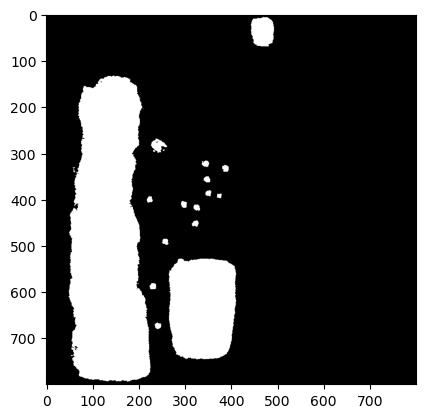

In [27]:
m = allmasks[0] > 0.5 
for i in range(18):
    m = m | (allmasks[i] > 0.5)
plt.imshow(m, cmap="gray")

In [192]:
target_df = target_df.iloc[2:]

In [24]:
slices = list(target_df["z"])
slices.extend(list(df["z"]))
slices = np.unique(slices)
slices

array([110, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190,
       195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255,
       260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320,
       325, 330, 335, 340, 345, 350, 355, 360, 365, 370, 375, 380, 385,
       390, 395, 400])

In [32]:
subdf = df[df["largest"] == "microtubule"]
subdf = subdf[subdf["label"] >= 0]
len(subdf)

32

In [ ]:
for n in ["microtubule", "nucleus", "endoplasmic_reticulum_or_Golgi", "mitochondria"]:
    pres = [] 
    gts = []
    for j in slices:
        s1 = []
        s2 = []
        sub1 = target_df[target_df["z"] == j]
        sub1 = sub1[sub1["name"] == n]
        sub2 = df[df["z"] == j]
        sub2 = sub2[sub2["largest"] == n]
        sub2 = sub2[sub2["label"] >= 0]
        for i, r in sub1.iterrows():
            s1.append(np.array([r["x1"], r["y1"], r["x2"], r["y2"]])) 
        for i, r in sub2.iterrows():
            s2.append(np.array([r["x1"], r["y1"], r["x2"], r["y2"]]))
        pres.append(s2)
        gts.append(s1)
        
    # if n == "endoplasmic_reticulum_or_Golgi":
    #     break
    print(n)
    # print(len(pres), len(gts))
    print(utils.calculate_ap(pres, gts, iou_thresholds=[0.5, 0.6, 0.7, 0.8, 0.9]))
        


microtubule
55 55
11 21 125
9 23 127
4 28 132
2 30 134
0 32 136
{'AP@50.0': 0.027803308823529414, 'AP@60.0': 0.018612132352941176, 'AP@70.0': 0.003676470588235294, 'AP@80.0': 0.0009191176470588235, 'AP@90.0': 0.0}
nucleus
55 55
18 1 8
15 4 11
15 4 11
12 7 14
4 15 22
{'AP@50.0': 0.6558704453441295, 'AP@60.0': 0.4554655870445344, 'AP@70.0': 0.4554655870445344, 'AP@80.0': 0.291497975708502, 'AP@90.0': 0.032388663967611336}
endoplasmic_reticulum_or_Golgi
55 55
75 136 65
69 147 71
56 162 84
23 195 117
3 215 137
{'AP@50.0': 0.19041976980365605, 'AP@60.0': 0.1574404761904762, 'AP@70.0': 0.10275229357798166, 'AP@80.0': 0.01733289646133683, 'AP@90.0': 0.00029488859764089124}
mitochondria
55 55
61 2 10
61 2 10
57 6 14
43 20 28
11 52 60
{'AP@50.0': 0.8318801699083389, 'AP@60.0': 0.8318801699083389, 'AP@70.0': 0.7263581488933603, 'AP@80.0': 0.41336910350994854, 'AP@90.0': 0.02705119606528057}


In [228]:
utils.calculate_iou(pres[8][0], gts[8][0])

0.7669873489812195

In [250]:
pres

[[],
 [array([263.37091064, 168.66052246, 421.24371338, 361.2350769 ]),
  array([272.37478638, 293.16397095, 368.96740723, 361.99594116]),
  array([269.28118896, 298.16659546, 337.55493164, 350.54064941])],
 [array([437.86102295,  24.49555016, 479.64996338,  75.21127319]),
  array([248.47450256, 173.94116211, 425.22964478, 348.67327881]),
  array([258.27441406, 270.66720581, 362.8822937 , 352.26464844])],
 [array([437.90899658,   5.12560606, 481.993927  ,  76.3041687 ])],
 [array([438.34024048,   2.51064014, 491.33154297,  65.96360016]),
  array([399.53585815, 307.14834595, 449.91549683, 366.27868652])],
 [array([436.65066528,   2.76953578, 489.64538574,  72.7530899 ]),
  array([404.74023438, 324.31719971, 448.33859253, 362.92068481])],
 [array([428.46270752,   0.        , 476.4329834 ,  62.92673492])],
 [array([407.00189209,   2.66823173, 485.30758667,  79.50053406]),
  array([252.6796875 , 225.42636108, 496.82885742, 373.92080688]),
  array([486.74282837, 231.2883606 , 527.46118164, 

In [252]:
importlib.reload(utils)
print(utils.calculate_ap(pres, gts, iou_thresholds=[0.2, 0.5, 0.6, 0.7, 0.8]))

38 157 11
35 179 14
28 189 21
20 197 29
7 210 42
{'AP@20.0': 0.1511250654107797, 'AP@50.0': 0.11682242990654206, 'AP@60.0': 0.07373271889400922, 'AP@70.0': 0.03761873412959654, 'AP@80.0': 0.004608294930875576}


In [251]:
gts

[[],
 [],
 [],
 [],
 [],
 [],
 [],
 [array([481.        ,   0.        , 558.99993896,  58.        ])],
 [array([475.        ,   0.        , 564.99993896,  63.        ]),
  array([542.,  74., 584., 113.])],
 [array([467.99996948,   0.        , 603.        , 121.        ])],
 [array([404.        ,   0.        , 481.99996948,  75.        ]),
  array([534.        ,  11.99999714, 658.        ,  91.99999237]),
  array([462.        ,   2.00000405, 643.        , 145.        ])],
 [array([407.00003052,   0.        , 471.99996948,  69.        ]),
  array([517.        ,  53.00000381, 662.        , 163.00001526]),
  array([526.,  12., 664.,  99.]),
  array([457.00003052,   4.00000048, 523.        ,  51.        ])],
 [array([388.        ,   0.        , 456.99996948,  58.99999619]),
  array([513.        ,   8.00000381, 683.        , 114.        ]),
  array([510.        ,  51.00000381, 673.        , 168.        ]),
  array([446.        ,   0.99999905, 514.00006104,  57.        ])],
 [array([497.99993

In [3]:
i="sllt0039_9.pkl"
dataset = modules.CocoDetection(
"/data/transformer_project/transforemer_model/train_data/training/data/", 
"/data/transformer_project/transforemer_model/train_data/training/data/annotations/"+i,
                            is_npy=True, filter_class=[3, 4, 7, 12, 14], map_class={"3":0, "4":1, "7":2, "12":3, "14":4}, require_mask=True, transform=utils.getConstantTransform(), add_classname=True, norm="hist",filtermin=5
)

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [ ]:
for i in range(len(dataset)):
    data = dataset[i]
    if data["labels"]["class_labels"].shape[0] > 0:
        print(data["labels"]["names"])
        # print(data["pixel_values"].shape)
        utils.drawannotation(data["pixel_values"], data["labels"], font_size=100)
        plt.show()
        # break
# data = dataset[8]
# utils.drawannotation(data["pixel_values"], data["labels"])